# Introduction to DEA Coastal Ecosystems <img align="right" src="../Supplementary_data/dea_logo.jpg">

* **[Sign up to the DEA Sandbox](https://app.sandbox.dea.ga.gov.au/)** to run this notebook interactively from a browser
* **Compatibility:** Notebook currently compatible with both the `NCI` and `DEA Sandbox` environments
* **Products used:** 
[ga_s2_coastalecosystems_cyear_3_v1](https://knowledge.dea.ga.gov.au/data/product/dea-coastal-ecosystems/),
[ga_s2ls_intertidal_cyear_3](https://knowledge.dea.ga.gov.au/data/product/dea-intertidal/)



## Background

Australia has extensive coastal ecosystems, including mangroves, saltmarshes, and seagrasses, that provide a wide range of ecosystem services. These services include carbon storage, habitat for aquatic and terrestrial species, and protection of coastlines from erosion and inundation.

The DEA Coastal Ecosystems product suite maps the extent of these ecosystems across Australia’s coastal zone, with a focus on areas landward of the low-tide boundary. A nationally consistent mapping approach was needed to support coastal management, environmental reporting, and informed decision-making at the national scale.

The DEA Coastal Ecosystems product was developed using a machine learning workflow that leveraged a methodology used to map shifts in Earth's tidal wetlands [Murray et al., 2022](https://www.science.org/doi/10.1126/science.abm9583).  Using Sentinel-2 data and derived datasets, the product suite provides an annual 10 m resolution extent classification layer for four ecosystem classes - mangrove, saltmarsh, intertidal flats, and intertidal seagrass - enabling users to better monitor and understand the distribution of these ecosystems at a continental scale. 

The classification layer is supported by individual ecosystem probability layers, to allow a more nuanced interpretation of the modelled ecosystem extents and to provide users flexibility for tailored mapping approaches. Data is available for the years 2021 and 2022.

### What this product offers

The DEA Coastal Ecosystems product suite offers users a categorical classification of four coastal ecosystems, supported by probability layers for individual ecosystems and selected quality assurance layers to support product interpretation. Key features of the product suite include:

* Sentinel-2 10 m resolution derived annual classification ecosystem maps, defining dominant ecosystem extents of mangroves, saltmarsh, intertidal, and intertidal seagrass.
* Probability layers for mapped ecosystems to enable user interpretation of mixed and transitional classes.
* QA/QC layers to provide confidence and assist in product interpretation.
* Publication of ancillary layers used for masking and constraints in the mapping workflow.
* Publication of the national training dataset, metadata, classification schema and acquisition protocol.

### Applications

* National Environmental Ecosystem Accounts
* National and Regional State of the Environment reporting
* A complementary mapping product to fill spatial and temporal gaps in higher resolution expert mapping (aerial and drone mapping, field surveys)
* Future integration with other terrestrial and ocean data sets (e.g. Land Cover and Marine Tenure)
* Coastal protection and Hazard modelling


## Description

This notebook will demonstrate how to load and analyse DEA Coastal Ecosystems using Digital Earth Australia. Topics covered include:

1. Inspecting the products and measurements available in the datacube.
2. Loading DEA Coastal Ecosystems for an example location, and exploring the five core layers of the product suite.
3. Plotting DEA Coastal Ecosystems data.
4. Extracting insights through basic analyses, including:
    - Calculating the ecosystem extents for a given area.
    - Visualise mixed and transitional ecosystems using a fractional cover approach, and
    - Empower users to develop their own categorical classification of coastal ecosystems.

This notebook is designed to be run with the default parameters, we suggest for first time users that you select `Run` (from the upper menu), followed by `Run All Cells`.

Following this, editable variables are identified that users can return to and adjust to suit their own needs and analyses.

<div class="alert alert-info">
    
**Note:** Visit the [DEA Coastal Ecoystems product documentation](https://knowledge.dea.ga.gov.au/data/product/dea-coastal-ecosystems/) for detailed technical information including methods, quality, and data access.
    
</div>

<div class="alert alert-info">

**Note:** Please be aware that this dataset includes a categorical <i>classification</i> layer as well as individual ecosystem <i>probability</i> layers. We advise that the <i>classification</i> layer be used to examine absolute ecosystem extents from year to year. To explore changing ecosystems, be aware that this workflow was designed to detect homogenous ecosystems only, but that the <i>probability</i> layers may give some indication of locations with mixed/transitional ecosystem classes.
</div>

***


## Getting started

To run this analysis, run all the cells in the notebook, starting with the "Load packages" cell. 

### Load packages
Import Python packages and load functions that are used for the analysis.

In [1]:
import datacube
import numpy as np
import pandas as pd
import xarray as xr
import odc.geo.xr

from dea_tools.maps import folium_map
import contextily as ctx
from IPython.display import display
from ipywidgets import HTML, HBox, Layout, VBox
from ipywidgets import Image as IPImage
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap

# Create mapping function to handle non-sequential categorical data
def remap_dataarray(da, value_to_index):
    """Remap DataArray values to sequential indices"""
    mapped_values = np.full_like(da.values, np.nan, dtype=float)
    for actual_val, index in value_to_index.items():
        mapped_values[da.values == actual_val] = index

    # Create new DataArray with same coordinates
    return xr.DataArray(mapped_values, coords=da.coords, dims=da.dims)

### Connect to the datacube

Connect to the datacube so we can access DEA data.

In [2]:
dc = datacube.Datacube(app="DEA_Coastal_Ecosystems")

## Available products and measurements

### List products available in Digital Earth Australia
We can use datacube's `list_products` functionality to inspect the DEA Coastal Ecosystem product that is available in Digital Earth Australia.
The table below shows the product name that we will use to load data, and a brief description of the product.

In [3]:
# List DEA Coastal Ecosystems products available in DEA
dc_products = dc.list_products()
dc_products.loc[["ga_s2_coastalecosystems_cyear_3_v1"]]

,name,description,license,default_crs,default_resolution
name,,,,,
ga_s2_coastalecosystems_cyear_3_v1,ga_s2_coastalecosystems_cyear_3_v1,Geoscience Australia Sentinel-2 Coastal Ecosys...,CC-BY-4.0,EPSG:3577,"(-10, 10)"


### List measurements
We can inspect the contents of the DEA Coastal Ecosystems product using datacube's `list_measurements` functionality.
The table below lists each of the measurements available in the product, which represent unique data variables that provide information about coastal ecosystems present in each pixel:

* `classification`: A high confidence categorical classifier of coastal ecosystem types. Classes: 2 = intertidal; 3 = mangrove; 4 = saltmarsh; 5 = intertidal seagrass.
* `*_prob`: Probability distributions for each coastal class.
* `qa_count_clear`: The count of clear and valid observations per pixel.
* `qa_coastal_connectivity`: Accumulated cost-distance coastal connectivity, used to identify likely coastal pixels.

The table also provides information about the measurement data types, units, nodata value and other technical information about each measurement.

In [4]:
dc_measurements = dc.list_measurements()
dc_measurements.loc[["ga_s2_coastalecosystems_cyear_3_v1"]]

name  \
product                            measurement                                        
ga_s2_coastalecosystems_cyear_3_v1 classification                    classification   
                                   mangrove_prob                      mangrove_prob   
                                   saltmarsh_prob                    saltmarsh_prob   
                                   saltflat_prob                      saltflat_prob   
                                   seagrass_prob                      seagrass_prob   
                                   qa_count_clear                    qa_count_clear   
                                   qa_coastal_connectivity  qa_coastal_connectivity   

                                                             dtype    units  \
product                            measurement                                
ga_s2_coastalecosystems_cyear_3_v1 classification            uint8    class   
                                   mangrove_prob             uint8  percent   
                                   saltmarsh_prob            uint8  percent   
                                   saltflat_prob             uint8  percent   
                                   seagrass_prob             uint8  percent   
                                   qa_count_clear            uint8    count   
                                   qa_coastal_connectivity  uint16     mask   

                                                           nodata  \
product                            measurement                      
ga_s2_coastalecosystems_cyear_3_v1 classification             255   
                                   mangrove_prob              255   
                                   saltmarsh_prob             255   
                                   saltflat_prob              255   
                                   seagrass_prob              255   
                                   qa_count_clear             255   
                                   qa_coastal_connectivity  65535   

                                                                           aliases  \
product                            measurement                                       
ga_s2_coastalecosystems_cyear_3_v1 classification                              NaN   
                                   mangrove_prob                               NaN   
                                   saltmarsh_prob                              NaN   
                                   saltflat_prob                               NaN   
                                   seagrass_prob                               NaN   
                                   qa_count_clear                    [count_clear]   
                                   qa_coastal_connectivity  [coastal_connectivity]   

                                                                                             flags_definition  
product                            measurement                                                                 
ga_s2_coastalecosystems_cyear_3_v1 classification           {'classification': {'bits': [0, 1, 2, 3, 4, 5,...  
                                   mangrove_prob                                                          NaN  
                                   saltmarsh_prob                                                         NaN  
                                   saltflat_prob                                                          NaN  
                                   seagrass_prob                                                          NaN  
                                   qa_count_clear                                                         NaN  
                                   qa_coastal_connectivity                                                NaN

## Loading data
Now that we know what products and measurements are available for the products, we can load data from Digital Earth Australia for an example location.
Leave the coordinates for Shoalwater Bay, Queensland for your first run-through.

<div class="alert alert-info">
    
**Note:** The spatial resolution of DEA Coastal Ecosystems is 10 metres. 
However, here we load the data at 30 m resolution to improve load times (e.g. `resolution=(-30, 30)`).
    
</div>


In [5]:
# Set a start and end date
start_time = "2021-01-01"
end_time = "2022-12-31"

query = {
    "y": (-22.4, -22.7),
    "x": (150.4, 150.8),
    "time": (start_time, end_time),
}

# Load DEA Coastal Ecosystems data from the datacube
ds = dc.load(product="ga_s2_coastalecosystems_cyear_3_v1", resolution=(-30, 30), **query)

# Mask nodata values in each band by setting to NaN
for var in ds.data_vars:
    ds[var] = ds[var].where(ds[var] != ds[var].nodata)

We can now view the data that we loaded.
The measurements listed under `Data variables` should match the measurements displayed in the previous [List measurements](#List-measurements) step.

In [6]:
ds

<xarray.Dataset> Size: 110MB
Dimensions:                  (time: 2, y: 1304, x: 1508)
Coordinates:
  * time                     (time) datetime64[ns] 16B 2021-07-02T11:59:59.99...
  * y                        (y) float64 10kB -2.547e+06 ... -2.586e+06
  * x                        (x) float64 12kB 1.867e+06 1.867e+06 ... 1.912e+06
    spatial_ref              int32 4B 3577
Data variables:
    classification           (time, y, x) float32 16MB nan nan nan ... nan nan
    mangrove_prob            (time, y, x) float32 16MB nan nan nan ... nan nan
    saltmarsh_prob           (time, y, x) float32 16MB nan nan nan ... nan nan
    saltflat_prob            (time, y, x) float32 16MB nan nan nan ... nan nan
    seagrass_prob            (time, y, x) float32 16MB nan nan nan ... nan nan
    qa_count_clear           (time, y, x) float32 16MB 49.0 49.0 ... 45.0 45.0
    qa_coastal_connectivity  (time, y, x) float32 16MB 0.0 0.0 0.0 ... 0.0 0.0
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

### Plotting data

First, we will set up a colour map to display the `classification` data:

In [7]:
# Set up the colormap for the classification
values = [2, 3, 4, 5]
colours = ["#94410d", "#29df3a", "#dbe436", "#0d834e"]  # QGIS colours
labels = ["Intertidal", "Mangroves", "Saltmarsh", "Intertidal\nSeagrass"]

# Create a custom colormap
cmap = mcolors.ListedColormap(colours)

# Define boundaries for discrete values
bounds = [v - 0.5 for v in values] + [values[-1] + 0.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

Now we can plot the categorical coastal ecosystem classification for two years of data side by side:

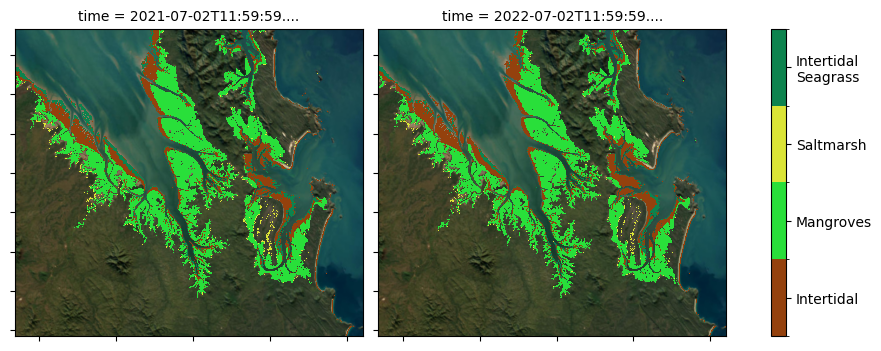

In [8]:
# Plot the classification layer for both years side by side
fig = ds.classification.plot(
    col="time",
    figsize=(10, 4),
    cmap=cmap,
    norm=norm,
    add_colorbar=False,
)

# Add a basemap and clean up axis labels
for ax in fig.axs.flat:
    ctx.add_basemap(
        ax=ax,
        crs=ds.odc.crs,
        source=ctx.providers.Esri.WorldImagery,
        attribution="",
        attribution_size=1,
    )
    ax.label_outer()
    ax.set_xticklabels(labels=[])
    ax.set_yticklabels(labels=[])
    ax.set_xlabel("")
    ax.set_ylabel("")

# Add the custom colormap
cbar = plt.colorbar(
    fig.axs.flat[0].collections[0],
    ax=fig.axs.ravel().tolist(),
    ticks=values,
)
cbar.ax.set_yticklabels(labels);

DEA Coastal Ecosystems has been produced for two years: 2021 and 2022.
Differences between the two years are subtle but can often be distinguished through differences in the seagrass class.

This categorical classification has been determined using the following probability layers as well as some context related masking.
The classification methodology is discussed in detail in the [DEA Knowledge Hub](https://knowledge.dea.ga.gov.au/data/product/dea-coastal-ecosystems/).

Briefly:
* Mangrove and saltmarsh ecosystems are classified if a pixel has >= 50% probability of belonging to the class
* Intertidal ecosystems have been mapped previously with a high level of confidence in the [DEA Intertidal](https://knowledge.dea.ga.gov.au/data/product/dea-intertidal/) product suite. These same extents are used in the DEA Coastal Ecosystems classification layer
* Intertidal seagrass was classified if located within the intertidal extent and had a probability of >= 70 %.

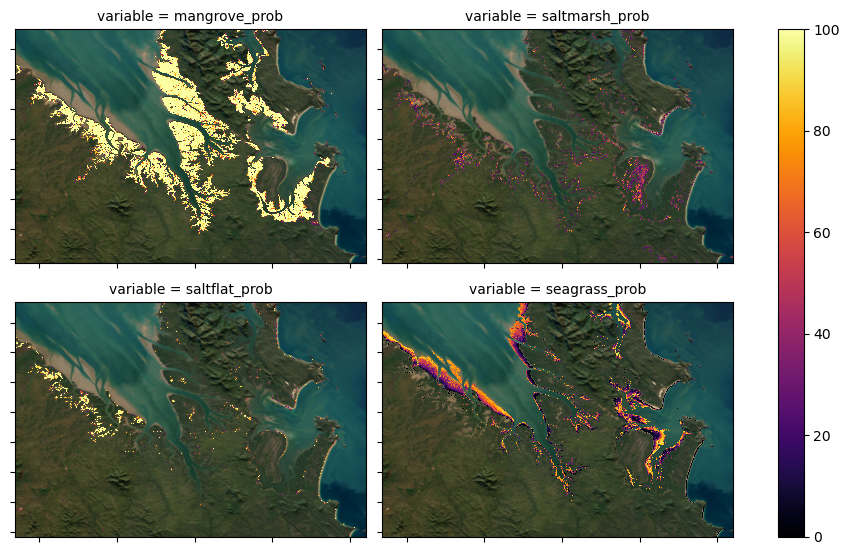

In [9]:
# Plot the probability layers for one year: 2021
fig = (
    ds.isel(time=0)[
        ["mangrove_prob", "saltmarsh_prob", "saltflat_prob", "seagrass_prob"]
    ]
    .to_array()
    .plot(col="variable", col_wrap=2, figsize=(10, 6), cmap="inferno")
)
# Add basemap and format axes of each subplot
for ax in fig.axs.flat:
    ctx.add_basemap(
        ax=ax,
        crs=ds.odc.crs,
        source=ctx.providers.Esri.WorldImagery,
        attribution="",
        attribution_size=1,
    )
    ax.label_outer()
    ax.set_xticklabels(labels="")
    ax.set_yticklabels(labels="")
    ax.set_xlabel("")
    ax.set_ylabel("")

The four classes in the categorical `classification` map include mangrove, saltmarsh, intertidal flats and intertidal seagrass. However, the four probability layers include mangrove, saltmarsh, saltflat and intertidal seagrass. Briefly, the reasoning for these class differences include:
- Intertidal flats have been mapped previously with a high level of confidence for the period of interest in the [DEA Intertidal](https://knowledge.dea.ga.gov.au/data/product/dea-intertidal/) product suite. These same extents are used in the DEA Coastal Ecosystems classification layer and were also used to limit the extents of the modelled intertidal seagrass. As the intertidal flats are a known extent, we did not publish a probability layer for them.
- The modelling used to generate the DEA Coastal Ecosystems product suite produced a probability extent for saltflat coastal ecosystems. The accuracy of saltflat modelling in the southern half of Australia was lower than our tolerance and the class was excluded from the continental `classification` map. In northern parts of Australia, the saltflat modelling is very good and the probabilities are included for use at a users own discretion.

<div class="alert alert-info">
    
**Note:** For a complete discussion regarding the decisions for the inclusion/exclusion of classes in the DEA Coastal Ecosystem product suite, please see the [DEA Knowledge Hub](https://knowledge.dea.ga.gov.au/data/product/dea-coastal-ecosystems/)
    
</div>

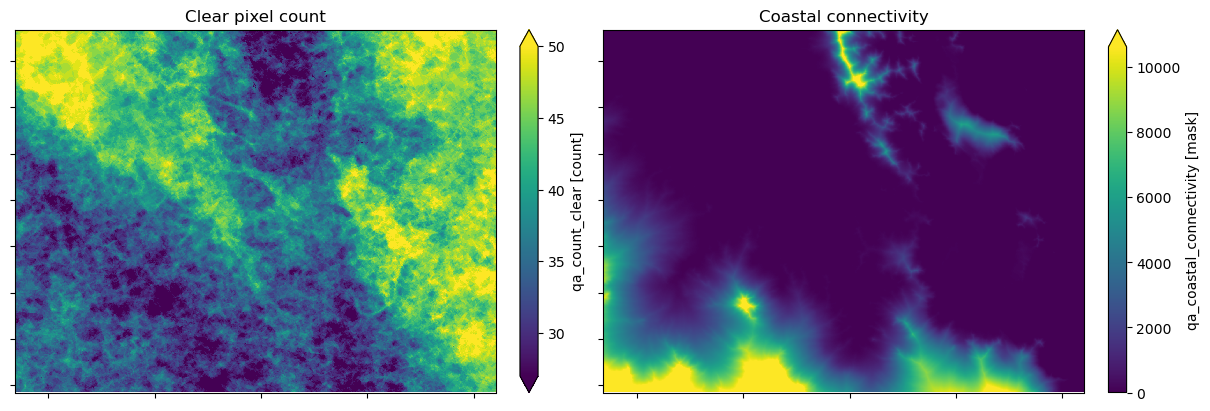

In [10]:
# Plot the quality-assurance layers for one year: 2021
fig, axs = plt.subplots(1, 2, figsize=(12, 4), layout='constrained')
ds.isel(time=0).qa_count_clear.plot(ax=axs[0], robust=True)
ds.isel(time=0).qa_coastal_connectivity.plot(ax=axs[1], robust=True)
axs[0].set_title("Clear pixel count")
axs[1].set_title("Coastal connectivity")

# for ax in fig.axes.flat:
for ax in range(0, 2):
    axs[ax].label_outer()
    axs[ax].set_xticklabels(labels="")
    axs[ax].set_yticklabels(labels="")
    axs[ax].set_xlabel("")
    axs[ax].set_ylabel("")

Annual modelling for DEA Coastal Ecosystems is completed using a single year of Sentinel-2 satellite observations.

Pixels with fewer than 10 clear and valid observations (geometrically accurate, cloud and glint-free) are excluded from the analysis.
A `clear pixel count` layer is included with the product to support users to interpret the data.

A `coastal connectivity` model was developed to support coastal ecosystem analysis in this product and the [DEA Intertidal](https://knowledge.dea.ga.gov.au/data/product/dea-intertidal/) product suite.
The model is a dimensionless representation of how connected pixels are to those at intertidal elevations.
The cost-distance weighted model assesses elevation and distance to represent highly connected coastal locations with low values.
Less connected areas that are either elevated or separated by distance are penalised with high values in the model.
The model is discussed further in the [DEA Knowledge Hub](https://knowledge.dea.ga.gov.au/data/product/dea-coastal-ecosystems/).
It is included as part of the product suite to support interpretation.

## Example application: calculating ecosystem extents

DEA Coastal Ecosystems `classification` data can be used to calculate the extent of coastal ecosystems for a given area.
This analysis will compare the mapped extents for both years of the dataset and return the extent in km^2.

In [11]:
# Define a dictionary to add interpretable labels to the data
key = {
    "0": "2021",
    "1": "2022",
    "2": "intertidal",
    "3": "mangrove",
    "4": "saltmarsh",
    "5": "seagrass",
}

# Summarise the ecosystem extents
px_count = []
for year in range(0, 2):
    for ecosystem in range(2, 6):
        count = ds["classification"].isel(time=year).where(ds["classification"].isel(time=year) == ecosystem).count()
        px_count.append((key[str(year)], key[str(ecosystem)], count.values))

# Translate to a dataframe
table = (
    pd.DataFrame(px_count, columns=["col", "row", "value"])
    .assign(value=lambda x: x["value"].apply(lambda y: y.item()))
    .pivot(index="row", columns="col", values="value")
)

# Calculate the extents in km2
table = np.round((table * 100) / 1000000, 2)

# Remove axis labels
table.index.name = None
table.columns.name = None

# Display the table
table

,2021,2022
intertidal,8.17,9.12
mangrove,21.94,22.22
saltmarsh,0.82,0.58
seagrass,3.24,2.33


## Example application: coastal ecosystem probability plots

The DEA Coastal Ecosystems `classification` layer identifies pixels with a high likelihood of belonging to the classified class.
However, the `probability` layers demonstrate that there is a spectrum of probabilities for these ecosystems and that they often overlap.

We can use colour to map the relative probability of our ecosystem classes for every pixel, plotting mangrove, saltmarsh and saltflat probability layers into one of the red, green, or blue channels of a multi-band image.
The ternary plot legend shows the relative percentage of each class that is represented in a pixel.
These plots may be useful to inform on ecosystem dynamics and the selection of probability thresholds for the determination of customised classifications (see the next section below).

Firstly, load a new data sample. 
Here, we've used the McArthur River in the Northern Territory.
Set your own coordinates to try a different location.

In [12]:
# Load data
query = {
    "y": (-15.8, -15.92),
    "x": (136.57, 136.74),
    "time": (start_time, end_time),
}

# Load DEA Coastal Ecosystems data from the datacube
ds = dc.load(product="ga_s2_coastalecosystems_cyear_3_v1", **query)

# Mask nodata values in each band by setting to NaN
for var in ds.data_vars:
    ds[var] = ds[var].where(ds[var] != ds[var].nodata)

Now we can plot our new data:

In [13]:
# Prepare the 2021 probability data
# Replace Nodata values with 0% probability
ds_nonan = ds[["mangrove_prob", "saltmarsh_prob", "saltflat_prob"]].sel(time="2021").fillna(0)

# Drop pixels where no probability is greater than 0
ds_nonan = ds_nonan.where(ds_nonan.to_array().max(dim="variable") > 0)

# Configure the colour style
rgb_ows_cfg = {
    "components": {
        "red": {"mangrove_prob": 1.0},
        "green": {"saltmarsh_prob": 1.0},
        "blue": {"saltflat_prob": 1.0},
    },
    "scale_range": (0, 100),
}

# Configure the ESRI basemap settings
tiles = "https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}"
attr = "Esri"

# Create folium map and convert to HTML widget
m = folium_map(
    ds_nonan,
    ows_style_config=rgb_ows_cfg,
    zoom_start=12,
    tiles=tiles,
    attr=attr,
)
folium_widget = HTML(value=m._repr_html_(), layout=Layout(width="60%"))

# Load the legend (png) as ipywidgets Image
with open("../Supplementary_data/DEA_Coastal_Ecosystems/coastal_ecosystem_fractional_cover_legend.png", "rb") as f:
    img_widget = IPImage(value=f.read(), format="png", layout=Layout(width="40%"))

# Create overall title
main_title = HTML(
    value='<h2 style="text-align: center; font-weight: bold; margin-bottom: 15px;">DEA Coastal Ecosystems probability plots (2021)</h2>'
)

# Create HBox with both components
content = HBox([folium_widget, img_widget])

# Wrap title and content in VBox
display(VBox([main_title, content]))

/env/lib/python3.10/site-packages/xarray/core/duck_array_ops.py:215: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


Use your mouse wheel or the +/- icons to interactively zoom around the coastal fractional cover dataset on the left hand side.

High probability mangrove classes are shown in red.
High probability saltmarsh classes are shown in green.
High probability saltflat classes are shown in blue.
50% / 50% saltflat and mangrove areas are shown in magenta.
50% / 50% mangrove and saltmarsh areas are shown in yellow.
50% / 50% saltmarsh and saltflat areas are shown in cyan.

Representing the coastal classes in this way demonstrates the difficulty in assigning exact extents to coastal ecosystems.

In the next section, you can use the probability layers to customise your own `classification` layer.
Use the fractional cover distributions to inform your choice of probability threshold.

### Example application: Create a custom classification

The DEA Coastal Ecosystems `classification` layer uses a series of thresholds and masks to create a meaningful continental and simultaneous classification of coastal ecosystems.

For local investigations, and/or to include a saltflat class, it may be beneficial to experiment with a custom classification, using the probability layers.

In this example, experiment with setting the `min_prob` value.
It is currently set to `min_prob = 40`. 
You might like to try `min_prob = 75` for example.
This will set the minimum probability value per class for consideration in the classification.

The DEA Coastal Ecosystems `classification` layer uses a separate threshold for intertidal seagrass (70%) compared to the other classes (50%).
If you feel comfortable experimenting, try setting different probability thresholds for the different classes (replacing the `min_prob` with an explicit value of your choice e.g. 65 for 65%)

In the cell below,
* You will identify your probability threshold

Then the code will:
* Prepare and combine the class_probability layers
* Create the classified layer by taking the class with the highest probability per pixel
* Create a sequential colourmap to plot the classification against (and ordering the data sequentially if required)
* Mapping your classification side by side with the DEA Coastal Ecosystems `classification` for comparison with ESRI WorldImagery beneath

**Below, set the new probability threshold**

In [14]:
# What is the minimum probability value for inclusion in the classification?
# Adjust this value only to apply the threshold to all classes in the classification.
min_prob = 40

Now, let's reclassify the probability layers by the new threshold set above:

In [15]:
# Load inter-tidal extent and threshold at min-prob
intertidal = dc.load(
    product="ga_s2ls_intertidal_cyear_3", measurements="extents", **query
)
intertidal = intertidal.extents.isel(time=0).where(intertidal.extents.isel(time=0) == 3)
intertidal = intertidal.where(intertidal.isnull(), min_prob)#.rename('intertidal')

# Prepare the input layers (customise the class thresholds by replacing min_prob)
# Mangrove
mangrove = ds.isel(time=0).mangrove_prob.where(ds.isel(time=0).mangrove_prob >= min_prob)
# Saltmarsh
saltmarsh = ds.isel(time=0).saltmarsh_prob.where(ds.isel(time=0).saltmarsh_prob >= min_prob)
# Saltflat
saltflat = ds.isel(time=0).saltflat_prob.where(ds.isel(time=0).saltflat_prob >= min_prob)
# Seagrass
seagrass = ds.isel(time=0).seagrass_prob.where(ds.isel(time=0).seagrass_prob >= min_prob)
# Intertidal
intertidal = intertidal.where(intertidal.isnull(), min_prob)

# Combine into a single dataset
dss = xr.Dataset()
dss["mangrove"] = mangrove
dss["saltmarsh"] = saltmarsh
dss["saltflat"] = saltflat
dss["seagrass"] = seagrass
dss["intertidal"] = intertidal


In [16]:
# Sum dataset to remove nans later
dss_sum = dss.to_array().sum(dim="variable")

# Define a dictionary to add interpretable labels to the data
key = {
    "mangrove": 3,
    "intertidal": 2,
    "saltmarsh": 4,
    "saltflat": 6,
    "seagrass": 5,
}

# Relabel string names with integer labels
data_vars = list(dss.data_vars.keys())
mapped_values = [key[var] for var in data_vars]

# Create a DataArray to store the classification
mapping_da = xr.DataArray(mapped_values, dims=["variable"])

# Classify the probability layers, taking argmax and directly index into the new DataArray
stacked = xr.concat([dss[var] for var in data_vars], dim="variable")

try:
    max_indices = stacked.argmax(dim="variable", skipna=True)
except ValueError:
    max_indices = stacked.fillna(-999).argmax(dim="variable")

max_mapped = mapping_da[max_indices]

# Create a mapping from indices to variable names
var_names = xr.DataArray(data_vars, dims=["variable"])
max_source_names = var_names[max_indices]

# Remove nan values
max_mapped = max_mapped.where(dss_sum != 0)

# Add classified layer and classified layer names to master dataset
dss["max"] = max_mapped
dss["max_name"] = max_source_names

# Dictionary to map values and plot colours against
Classified_labels = {
    2: ["Intertidal", "#94410d"],
    3: ["Mangrove", "#29df3a"],
    4: ["Saltmarsh", "#dbe436"],
    5: ["Intertidal\nSeagrass", "#0d834e"],
    6: ["Saltflat", "darkkhaki"],
}  # Set as transparent

# Get unique values to ensure consistent mapping
unique_values = key.values()

# Prepare colorbar
categories = []
colours = []
for val in unique_values:
    categories.append(Classified_labels[val][0])
    colours.append(Classified_labels[val][1])

# Create a discrete colormap
cmap1 = ListedColormap(colours[: len(unique_values)])

# Create boundaries for the colormap
bounds1 = np.arange(len(unique_values) + 1) - 0.5
norm1 = BoundaryNorm(bounds1, cmap1.N)

# Create new xarray DataArrays with mapped values for use in `remap_dataarray` function
value_to_index = {val: i for i, val in enumerate(unique_values)}

# Remap non-sequential categories as sequential
reclassified = remap_dataarray(dss["max"], value_to_index)

and now plot the results of the custom classification, after creating a custom colourbar:

In [17]:
Classified_labels = {
    2: ["Intertidal", "#94410d"],
    3: ["Mangrove", "#29df3a"],
    4: ["Saltmarsh", "#dbe436"],
    5: ["Intertidal\nSeagrass", "#0d834e"],
    6: ["Saltflat", "darkkhaki"],
}  # Set as transparent

# Prepare colorbar
categories = []
colours = []
for val in unique_values:
    categories.append(Classified_labels[val][0])
    colours.append(Classified_labels[val][1])

# Create a discrete colormap
cmap1 = ListedColormap(colours[: len(unique_values)])

# Create boundaries for the colormap
bounds1 = np.arange(len(unique_values) + 1) - 0.5
norm1 = BoundaryNorm(bounds1, cmap1.N)

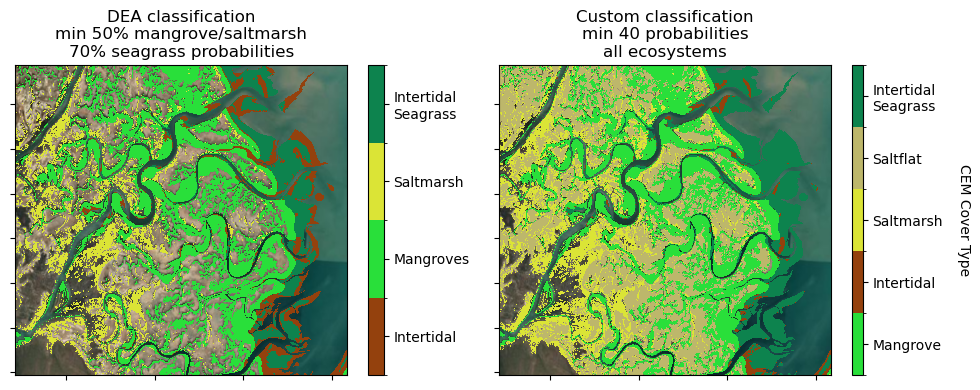

In [18]:
# Plot using xarray over Esri WorldImagery basemap
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

im1 = reclassified.plot(ax=ax[1], cmap=cmap1, norm=norm1, add_colorbar=False)
ax[1].set_title(f"Custom classification\nmin {min_prob} probabilities\nall ecosystems")

im0 = (
    ds["classification"]
    .isel(time=0)
    .plot(ax=ax[0], cmap=cmap, norm=norm, add_colorbar=False)
)
ax[0].set_title(
    "DEA classification\nmin 50% mangrove/saltmarsh\n70% seagrass probabilities"
)

# Add shared colorbar using the returned image object
cbar = plt.colorbar(im1, ticks=np.arange(len(unique_values)),  aspect=30)
cbar.set_ticklabels(categories[: len(unique_values)])
cbar.set_label("CEM Cover Type", rotation=270, labelpad=20)

# Add custom colorbar
cbar = plt.colorbar(
    im0,
    ax=ax[0],
    ticks=values,
)
cbar.ax.set_yticklabels(labels)

# format plots and add basemap
for axis in ax:
    ctx.add_basemap(
        ax=axis,
        crs=reclassified.odc.crs,
        source=ctx.providers.Esri.WorldImagery,
        attribution="",
        attribution_size=1,
    )
    axis.label_outer()
    axis.set_xticklabels(labels="")
    axis.set_yticklabels(labels="")
    axis.set_xlabel("")
    axis.set_ylabel("")

plt.tight_layout();

***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Australia data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Discord chat](https://discord.com/invite/4hhBQVas5U) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [GitHub](https://github.com/GeoscienceAustralia/dea-notebooks).

**Last modified:** December 2025

**Compatible datacube version:** 

In [19]:
print(datacube.__version__)

1.8.19
